In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [ ]:
df = pd.read_csv("/content/hand_dataset.csv")

In [ ]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,output
0,388,410,305,424,221,367,176,302,150,249,...,309,369,256,352,214,361,266,365,294,A
1,394,412,303,422,223,367,182,297,155,244,...,302,374,252,356,211,367,262,373,284,A
2,395,413,303,421,225,363,185,288,156,234,...,300,376,247,358,205,368,260,374,284,A
3,397,419,303,424,222,368,177,297,150,241,...,303,376,250,356,208,366,262,373,287,A
4,401,417,306,425,225,368,182,292,151,237,...,300,379,246,358,203,369,259,376,283,A


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 316 entries, 0 to 315
Data columns (total 43 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       316 non-null    int64 
 1   1       316 non-null    int64 
 2   2       316 non-null    int64 
 3   3       316 non-null    int64 
 4   4       316 non-null    int64 
 5   5       316 non-null    int64 
 6   6       316 non-null    int64 
 7   7       316 non-null    int64 
 8   8       316 non-null    int64 
 9   9       316 non-null    int64 
 10  10      316 non-null    int64 
 11  11      316 non-null    int64 
 12  12      316 non-null    int64 
 13  13      316 non-null    int64 
 14  14      316 non-null    int64 
 15  15      316 non-null    int64 
 16  16      316 non-null    int64 
 17  17      316 non-null    int64 
 18  18      316 non-null    int64 
 19  19      316 non-null    int64 
 20  20      316 non-null    int64 
 21  21      316 non-null    int64 
 22  22      316 non-null    in

In [ ]:
df.isnull().sum().sum()

np.int64(0)

<Axes: xlabel='output', ylabel='count'>

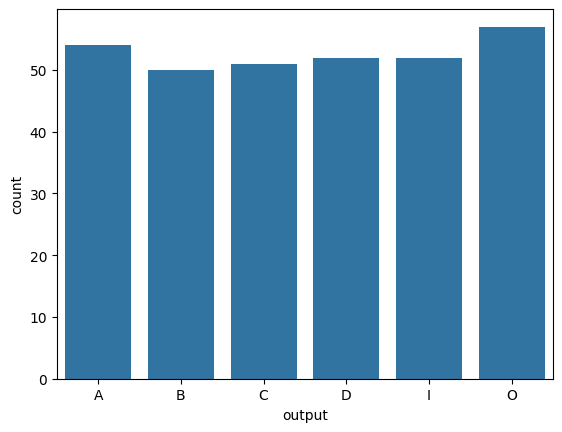

In [ ]:
sns.countplot(x=df['output'])

In [ ]:
X = df.drop('output',axis= 1)
y= df['output']

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1,shuffle=True,random_state=42,stratify=y)

In [ ]:
X_train.shape,X_test.shape,y_train.shape,y_test .shape

((284, 42), (32, 42), (284,), (32,))

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression()

In [ ]:
model.fit(X_train,y_train)

LogisticRegression()

In [ ]:
model.score(X_train,y_train)

0.9929577464788732

In [ ]:
model.score(X_test,y_test)

1.0

In [ ]:
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report

In [ ]:
y_pred,y_test

(array(['D', 'O', 'B', 'O', 'C', 'D', 'I', 'O', 'A', 'A', 'D', 'I', 'B',
        'C', 'A', 'D', 'B', 'A', 'A', 'C', 'I', 'B', 'O', 'C', 'B', 'I',
        'C', 'I', 'O', 'A', 'D', 'O'], dtype=object),
 204    D
 306    O
 100    B
 274    O
 108    C
 182    D
 250    I
 307    O
 51     A
 20     A
 160    D
 238    I
 61     B
 144    C
 7      A
 198    D
 60     B
 42     A
 28     A
 145    C
 225    I
 97     B
 310    O
 142    C
 88     B
 208    I
 136    C
 232    I
 284    O
 14     A
 199    D
 260    O
 Name: output, dtype: object)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           A       1.00      1.00      1.00         6
           B       1.00      1.00      1.00         5
           C       1.00      1.00      1.00         5
           D       1.00      1.00      1.00         5
           I       1.00      1.00      1.00         5
           O       1.00      1.00      1.00         6

    accuracy                           1.00        32
   macro avg       1.00      1.00      1.00        32
weighted avg       1.00      1.00      1.00        32

